In [1]:
%matplotlib widget 
import numpy as np
import torch
import os
from DS3Dplus.ds3d_utils import Sampling, calc_jaccard_rmse, Volume2XYZ
import matplotlib.pyplot as plt
import pickle
from skimage import io
from torch.nn.functional import interpolate
import time
from datetime import datetime
# import csv
from numpy import pi
from torch import nn
from numpy import savetxt
import torch.fft as fft
import torch.nn.functional as F
from misc2 import image_cropping
from DS3Dplus.lens_utils import LensModelBase, LensModelTraining


In [2]:
training_result_path = os.path.join(os.getcwd(), "training_results", "tank_tp16_01-26_10-07")  # new net for tp16
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

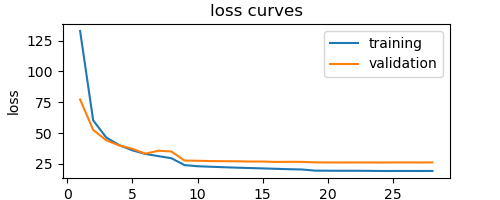

In [3]:
with open(os.path.join(training_result_path, 'fit.pickle'), 'rb') as handle:
    fit_result = pickle.load(handle)
num_epochs = fit_result.num_epochs
train_loss = fit_result.train_loss
test_loss = fit_result.test_loss

num_epochs = len(train_loss)
plt.figure(figsize=(5, 2))
plt.plot(np.arange(1, num_epochs+1), train_loss, label='training')
plt.plot(np.arange(1, num_epochs+1), test_loss, label='validation')
plt.legend()
plt.title('loss curves')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()


In [4]:
with open(os.path.join(training_result_path, 'param.pickle'), 'rb') as handle:
    param_dict = pickle.load(handle)
param_dict['device'] = device
checkpoint = torch.load(os.path.join(training_result_path, "net.pt"), map_location=device)
net = checkpoint['net']
net.load_state_dict(checkpoint['state_dict'])

model = LensModelTraining(param_dict)

# experiments

In [5]:

center_x = 1061
center_y = 1092
real_pixel_size = 0.0392 # mm

exp_imgs_path = os.path.join(os.getcwd(), "data", "tank16") 
img_names = sorted(os.listdir(exp_imgs_path))

shift_x = -100
center_x = center_x+shift_x

num_imgs = len(img_names)
print(f'the number of images: {num_imgs}')

the number of images: 5


In [6]:
im_idx = 0  # test on the idx image
im_path = os.path.join(exp_imgs_path, img_names[im_idx])
im_full = io.imread(im_path).astype(np.float32)[center_y-300:center_y+300+1, center_x-300:center_x+300+1]
print(f'image shape: {im_full.shape}')

image shape: (601, 601)


In [7]:
# the cropping is only for test
# ensure the sub image size is smaller than model.N
num_row = 3
num_col = 3
img_set = image_cropping(im_full, num_row, num_col)
print(f'imaging model size: {model.N}')
print(f'subimage size: {img_set[0][0].shape}')

imaging model size: 255
subimage size: (201, 201)


In [8]:
xyz_set = []
conf_set = []

param_dict['threshold'] = 80
volume2xyz = Volume2XYZ(param_dict)
with torch.no_grad():
    net.eval()
    for i in range(num_row):
        xyz_ = []
        conf_ = []
        for j in range(num_col):
            im = img_set[i][j]
            if param_dict['project_01']:
                im = ((im - im.min()) / (im.max() - im.min())).astype(np.float32)
            vol = net(torch.from_numpy(im[np.newaxis, np.newaxis, :, :]).to(device))
            xyz_rec, conf_rec = volume2xyz(vol)
            xyz_.append(xyz_rec)
            conf_.append(conf_rec)
        xyz_set.append(xyz_)
        conf_set.append(conf_)
        

found 266 particles


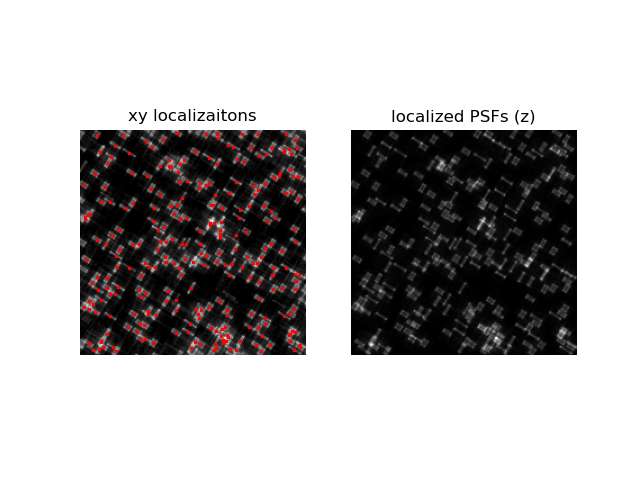

In [9]:
r_idx = 0
c_idx = 0

im, xyz_rec, conf_rec = img_set[r_idx][c_idx], xyz_set[r_idx][c_idx], conf_set[r_idx][c_idx]   

if xyz_rec is not None:
    print(f'found {xyz_rec.shape[0]} particles')
    # print(f'particles per pixel (ppp): {xyz_rec.shape[0]/(im.shape[0]*im.shape[1])}')
    # print(f'particles per mm3: {xyz_rec.shape[0]/(im.shape[0]*im.shape[1]*real_pixel_size**2*22)}')

    param_dict['im_size'] = im.shape

    model = LensModelTraining(param_dict)

    nphotons_rec = (param_dict['Nsig_range'][0]+param_dict['Nsig_range'][1])/2 * np.ones(xyz_rec.shape[0])
    # psfs_rec = model.get_psfs(torch.from_numpy(np.c_[xyz_rec, nphotons_rec]).to(device)).cpu().numpy()
    # im_rec = np.sum(psfs_rec, axis=0)
    im_rec = model(torch.from_numpy(np.c_[xyz_rec, nphotons_rec]).to(device))
    
    # plot
    ps_xy = param_dict['vs_xy']*param_dict['us_factor']
    h, w = im.shape
    ch, cw = (h-1)/2, (w-1)/2
    
    plt.close()
    f, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)

    ax1.imshow(im, cmap='gray')
    ax1.plot(xyz_rec[:, 0] / ps_xy + cw, xyz_rec[:, 1] / ps_xy + ch, 'rx', markersize=2)
    ax1.set_title('xy localizaitons')
    ax1.axis('off')

    # ax2.imshow(np.sum(psfs_rec, axis=0), cmap='gray')
    ax2.imshow(im_rec, cmap='gray')
    ax2.set_title('localized PSFs (z)')
    ax2.axis('off')

    # plt.savefig('overlay.jpg', bbox_inches='tight', dpi=600)

    plt.show()
else:
    plt.figure()
    plt.imshow(im, cmap='gray')
    plt.title('no particle')
    plt.axis('off')
    plt.show()
    
    
    

found 2525 particles
particles per pixel (ppp): 0.0069905675787165595
particles per mm3: 0.20678432928977744


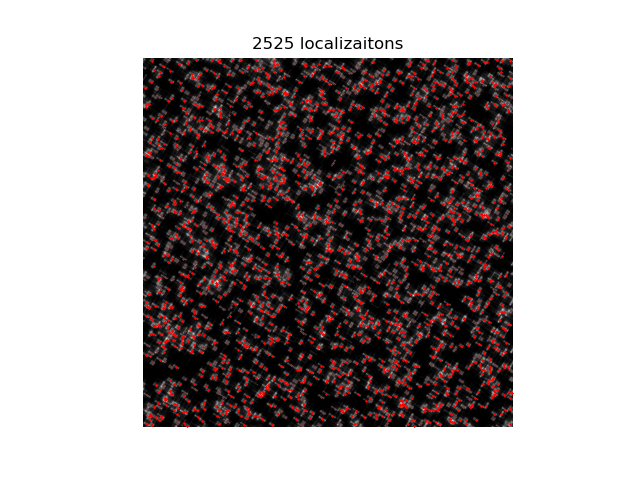

In [10]:
# show the full image detection
im = im_full
with torch.no_grad():
    net.eval()
    if param_dict['project_01']:
        im = ((im - im.min()) / (im.max() - im.min())).astype(np.float32)
    vol = net(torch.from_numpy(im[np.newaxis, np.newaxis, :, :]).to(device))
    xyz_rec, conf_rec = volume2xyz(vol)

    print(f'found {xyz_rec.shape[0]} particles')
    print(f'particles per pixel (ppp): {xyz_rec.shape[0]/(im.shape[0]*im.shape[1])}')
    print(f'particles per mm3: {xyz_rec.shape[0]/(im.shape[0]*im.shape[1]*real_pixel_size**2*22)}')


h, w = im.shape
ch, cw = (h-1)/2, (w-1)/2

f, ax1 = plt.subplots(1, 1)
ax1.imshow(im, cmap='gray')
ax1.plot(xyz_rec[:, 0] / ps_xy + cw, xyz_rec[:, 1] / ps_xy + ch, 'rx', markersize=1)
ax1.set_title(f'{xyz_rec.shape[0]} localizaitons')
ax1.axis('off')
plt.show()

In [15]:
# process all the images
# time of the entire dataset analysis
tall_start = time.time()
# needed pixel-size for plotting if only few images are in the folder
ps_xy = param_dict['ps_xy'] # FOV size, camera pixel size/magnification
# process all experimental images

results = np.array(['frame', 'x [nm]', 'y [nm]', 'z [nm]', 'intensity [au]'])
with torch.no_grad():
    net.eval()
    for im_ind, im_name in enumerate(img_names):
        # time each frame
        tfrm_start = time.time()

        # im = io.imread(os.path.join(exp_imgs_path, im_name)).astype(np.float32)[center_y-400:center_y+400+1, center_x-400:center_x+400+1]  # alignment FOV
        im = io.imread(os.path.join(exp_imgs_path, im_name)).astype(np.float32)[center_y-600:center_y+600+1, center_x-400:center_x+400+1]
        
        if param_dict['project_01']:
            im = ((im - im.min()) / (im.max() - im.min())).astype(np.float32)
        vol = net(torch.from_numpy(im[np.newaxis, np.newaxis, :, :]).to(device))
        xyz_rec, conf_rec = volume2xyz(vol)

        # time it takes to analyze a single frame
        tfrm_end = time.time() - tfrm_start

        # if this is the first image, get the dimensions and the relevant center for plotting
        if im_ind == 0:
            H, W = im.shape
            ch, cw = H / 2, W / 2

        # if prediction is empty then set number fo found emitters to 0
        # otherwise generate the frame column and append results for saving
        if xyz_rec is None:
            nemitters = 0
        else:
            nemitters = xyz_rec.shape[0]
            frm_rec = (im_ind + 1) * np.ones(nemitters)
            
            xnm = xyz_rec[:, 0]*real_pixel_size
            ynm = xyz_rec[:, 1]*real_pixel_size
            znm = (xyz_rec[:, 2])
            
            xyz_save = np.c_[xnm, ynm, znm]
            
            results = np.vstack((results, np.column_stack((frm_rec, xyz_save, conf_rec))))
            if im_ind % (num_imgs // 10) == 0:
                print('Processed Image [%d/%d]' % (im_ind + 1, num_imgs))
                # print status
                print('Single frame complete in {:.6f}s, found {:d} emitters'.format(tfrm_end, nemitters))

# print the time it took for the entire analysis
tall_end = time.time() - tall_start
print('=' * 50)
print('Analysis complete in {:.0f}h {:.0f}m {:.0f}s'.format(
    tall_end // 3600, np.floor((tall_end / 3600 - tall_end // 3600) * 60), tall_end % 60))
print('=' * 50)

time_now = datetime.today().strftime('%m-%d_%H-%M')
file_name = exp_imgs_path + "_loc_" + time_now
data = results[1:, :].astype(np.float32)  # no title, required by myptv
data = np.hstack((data[:, 1:], data[:, [0]]-1)) # arrange such that frame index is the last, required by the tracking algorithm myptv
savetxt(file_name, data, delimiter='\t', fmt=['%.9g', '%.9g', '%.9g', '%.1f', '%d'])  # x, y, z, intensity, frame index

print(f'{file_name} is saved.')


Processed Image [1/311]
Single frame complete in 1.269852s, found 2984 emitters
Processed Image [32/311]
Single frame complete in 0.951099s, found 2951 emitters
Processed Image [63/311]
Single frame complete in 1.070323s, found 2891 emitters
Processed Image [94/311]
Single frame complete in 1.044446s, found 2824 emitters
Processed Image [125/311]
Single frame complete in 0.965905s, found 2805 emitters
Processed Image [156/311]
Single frame complete in 1.049737s, found 2780 emitters
Processed Image [187/311]
Single frame complete in 1.056848s, found 2806 emitters
Processed Image [218/311]
Single frame complete in 0.950685s, found 2815 emitters
Processed Image [249/311]
Single frame complete in 0.919047s, found 2810 emitters
Processed Image [280/311]
Single frame complete in 0.836061s, found 2813 emitters
Processed Image [311/311]
Single frame complete in 0.652377s, found 2804 emitters
Analysis complete in 0h 6m 18s
/bigdata/dafei/PIV_data/PSFE/exp20251218/D400_TP_Jet_r2_loc_02-02_20-46 

# apply alignment registration between tomo and psfe


In [3]:
from misc2 import XYZTransform
import numpy as np
import os 

In [4]:
# alignment_file = 'alignment16_0127_1000.npy'  # tp16, new net, FOV 1000

alignment_file = os.path.join(os.getcwd(), "data", "alignment16_0127_1000.npy")

alignment_dict = np.load(alignment_file, allow_pickle=True).item()
xyzfunc = XYZTransform(alignment_dict)

In [18]:
# apply alignment registration
fname = file_name  # take the file above
# fname = '/bigdata/dafei/PIV_data/PSFE/exp20251216/D800_TP_Swirl_R1_loc_01-26_21-06'  # new net

psfe_data = np.loadtxt(fname)
if shift_x != 0:
    psfe_data[:, 0] = psfe_data[:, 0]+shift_x*real_pixel_size
    
psfe_data[:, :3] = xyzfunc(psfe_data[:, :3])  # xyz alignment

fname_reg = fname + '_reg'
savetxt(fname_reg, psfe_data, delimiter='\t', fmt=['%.9g', '%.9g', '%.9g', '%.1f', '%d'])
